# Configuration

In [106]:
import os
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [107]:
DATA_PATH = "../emissions-data"

TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

WINDOW_SIZE = 168              # 7 days history
FORECAST_HORIZON = 24          # predict next 24 hours
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.3                  # increased from 0.2 to combat overfitting
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 64                # increased from 32 — smoother gradients, less overfitting

LOG_DIR = "logs_lstm"
MODEL_DIR = "saved_model_lstm"
TFLITE_PATH = "carbon_model_lstm.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Load & Preprocess Data

In [108]:
csv_files = sorted(glob.glob(os.path.join(DATA_PATH, "*.csv")))
df = pd.concat((
    pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files),
    ignore_index=True)
df = df.sort_values("Datetime (UTC)").reset_index(drop=True)

# Time features
df["hour"] = df["Datetime (UTC)"].dt.hour
df["day_of_year"] = df["Datetime (UTC)"].dt.dayofyear

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

# Differencing (computed BEFORE scaling — will be scaled together with target later)
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

# Drop NaN rows from differencing (only first 24 rows)
df = df.dropna(subset=["diff_1", "diff_24"]).reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['Datetime (UTC)'].min()} to {df['Datetime (UTC)'].max()}")
print(f"\nRows per year:")
print(df["Datetime (UTC)"].dt.year.value_counts().sort_index())

Total rows: 43800
Date range: 2021-01-02 00:00:00 to 2025-12-31 23:00:00

Rows per year:
Datetime (UTC)
2021    8736
2022    8760
2023    8760
2024    8784
2025    8760
Name: count, dtype: int64


# Split Data

In [109]:
train = df[(df["Datetime (UTC)"].dt.year >= 2021) &
           (df["Datetime (UTC)"].dt.year <= 2023)]

val = df[df["Datetime (UTC)"].dt.year == 2024]
test = df[df["Datetime (UTC)"].dt.year == 2025]

print(f"Train: {len(train)} rows ({train['Datetime (UTC)'].min()} to {train['Datetime (UTC)'].max()})")
print(f"Val:   {len(val)} rows ({val['Datetime (UTC)'].min()} to {val['Datetime (UTC)'].max()})")
print(f"Test:  {len(test)} rows ({test['Datetime (UTC)'].min()} to {test['Datetime (UTC)'].max()})")

Train: 26256 rows (2021-01-02 00:00:00 to 2023-12-31 23:00:00)
Val:   8784 rows (2024-01-01 00:00:00 to 2024-12-31 23:00:00)
Test:  8760 rows (2025-01-01 00:00:00 to 2025-12-31 23:00:00)


In [110]:
print(df["Datetime (UTC)"].dt.year.value_counts().sort_index())

Datetime (UTC)
2021    8736
2022    8760
2023    8760
2024    8784
2025    8760
Name: count, dtype: int64


# Normalization

**FIX: Scale ALL features together, not just target.**
The original notebook only scaled the target column but left `diff_1` and `diff_24` on their raw scale.
LSTM gates are sigmoid-based and saturate on mixed-scale inputs, causing the model to collapse to mean prediction.

In [111]:
FEATURES = [
    TARGET_COL,
    "diff_1",
    "diff_24",
    "hour_sin",
    "hour_cos",
    "year_sin",
    "year_cos"
]

# Scale ALL features together using one StandardScaler
feature_scaler = StandardScaler()

train = train.copy()
val = val.copy()
test = test.copy()

train[FEATURES] = feature_scaler.fit_transform(train[FEATURES])
val[FEATURES] = feature_scaler.transform(val[FEATURES])
test[FEATURES] = feature_scaler.transform(test[FEATURES])

# Extract target-only scaler for inverse_transform at inference
target_idx = FEATURES.index(TARGET_COL)
target_scaler = StandardScaler()
target_scaler.mean_ = np.array([feature_scaler.mean_[target_idx]])
target_scaler.scale_ = np.array([feature_scaler.scale_[target_idx]])
target_scaler.var_ = np.array([feature_scaler.var_[target_idx]])
target_scaler.n_features_in_ = 1
target_scaler.n_samples_seen_ = feature_scaler.n_samples_seen_

# Save scaler parameters for Android (target only — for inverse_transform)
# Save scaler parameters for Android
scaler_params = {
    "target_mean": target_scaler.mean_.tolist(),
    "target_scale": target_scaler.scale_.tolist(),
    "feature_names": FEATURES,
    "feature_means": feature_scaler.mean_.tolist(),
    "feature_scales": feature_scaler.scale_.tolist(),
}
with open("scaler_params_v1.json", "w") as f:
    json.dump(scaler_params, f, indent=4)

print(f"Target scaler — mean: {target_scaler.mean_[0]:.2f}, scale: {target_scaler.scale_[0]:.2f}")
print(f"\nAll feature means:  {dict(zip(FEATURES, feature_scaler.mean_.round(2)))}")
print(f"All feature scales: {dict(zip(FEATURES, feature_scaler.scale_.round(2)))}")

Target scaler — mean: 119.08, scale: 63.90

All feature means:  {'Carbon intensity gCO₂eq/kWh (direct)': np.float64(119.08), 'diff_1': np.float64(-0.0), 'diff_24': np.float64(-0.04), 'hour_sin': np.float64(-0.0), 'hour_cos': np.float64(-0.0), 'year_sin': np.float64(-0.0), 'year_cos': np.float64(-0.0)}
All feature scales: {'Carbon intensity gCO₂eq/kWh (direct)': np.float64(63.9), 'diff_1': np.float64(15.17), 'diff_24': np.float64(48.93), 'hour_sin': np.float64(0.71), 'hour_cos': np.float64(0.71), 'year_sin': np.float64(0.71), 'year_cos': np.float64(0.71)}


# Create Windowed Dataset

In [112]:
def create_dataset(data):
    x, y = [], []
    values = data[FEATURES].values
    target = data[TARGET_COL].values

    for i in range(WINDOW_SIZE, len(data) - FORECAST_HORIZON):
        x.append(values[i-WINDOW_SIZE:i])
        y.append(target[i:i+FORECAST_HORIZON])

    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train)
x_val, y_val = create_dataset(val)
x_test, y_test = create_dataset(test)

print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_val:   {x_val.shape}  | y_val:   {y_val.shape}")
print(f"x_test:  {x_test.shape}  | y_test:  {y_test.shape}")

# Sanity check: verify features are on similar scales
print(f"\nFeature stats in x_train (should all be ~mean 0, std 1):")
for i, f in enumerate(FEATURES):
    vals = x_train[:, :, i].flatten()
    print(f"  {f:45s}: mean={vals.mean():.3f}, std={vals.std():.3f}")

x_train: (26064, 168, 7) | y_train: (26064, 24)
x_val:   (8592, 168, 7)  | y_val:   (8592, 24)
x_test:  (8568, 168, 7)  | y_test:  (8568, 24)

Feature stats in x_train (should all be ~mean 0, std 1):
  Carbon intensity gCO₂eq/kWh (direct)         : mean=0.000, std=1.002
  diff_1                                       : mean=-0.000, std=1.002
  diff_24                                      : mean=-0.000, std=1.002
  hour_sin                                     : mean=-0.000, std=1.000
  hour_cos                                     : mean=0.000, std=1.000
  year_sin                                     : mean=-0.000, std=1.004
  year_cos                                     : mean=-0.010, std=0.996


# Build LSTM Model

**FIX: Added L2 regularization to LSTM layers to reduce overfitting.**
**FIX: Added BatchNormalization between layers for training stability.**

In [113]:
num_features = len(FEATURES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, num_features)),

    # LSTM layer 1 — captures long-range temporal dependencies
    tf.keras.layers.LSTM(
        HIDDEN_SIZE,
        return_sequences=True,
        unroll=True,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(DROPOUT),

    # LSTM layer 2 — compresses sequence to single vector
    tf.keras.layers.LSTM(
        HIDDEN_SIZE,
        return_sequences=False,
        unroll=True,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(DROPOUT),

    # Dense head
    tf.keras.layers.Dense(HIDDEN_SIZE, activation="relu"),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(FORECAST_HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 168, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,176 (223.34 KB)

 Trainable params: 57,176 (223.34 KB)

 Non-trainable params: 0 (0.00 B)

# Callbacks

**FIX: Reduced EarlyStopping patience from 10 to 5.**
The original ran ~11 epochs with val_loss rising from epoch 3 onward — patience=10 let it overfit for 8 extra epochs.

In [114]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)

csv_logger = tf.keras.callbacks.CSVLogger("training_log_lstm.csv")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,              # reduced from 10
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3               # reduced from 4
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model.keras"),
    monitor="val_loss",
    save_best_only=True
)

# Train

In [115]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tensorboard_cb, csv_logger, early_stop, reduce_lr, checkpoint]
)

Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 66s 73ms/step - loss: 0.4677 - mae: 0.4967 - val_loss: 0.2685 - val_mae: 0.3832 - learning_rate: 0.0010
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - loss: 0.3938 - mae: 0.4591 - val_loss: 0.2923 - val_mae: 0.4135 - learning_rate: 0.0010
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - loss: 0.3752 - mae: 0.4492 - val_loss: 0.2679 - val_mae: 0.3825 - learning_rate: 0.0010
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - loss: 0.3598 - mae: 0.4421 - val_loss: 0.2763 - val_mae: 0.3885 - learning_rate: 0.0010
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - loss: 0.3358 - mae: 0.4297 - val_loss: 0.2878 - val_mae: 0.3962 - learning_rate: 0.0010
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - loss: 0.3185 - mae: 0.4210 - val_loss: 0.2978 - val_mae: 0.4026 - learning_rate: 0.0010
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - loss: 0.2886 - mae: 0.4027 - val_loss: 0.3014 - val_mae: 0.3920 - learning_rate:

# Training Curves

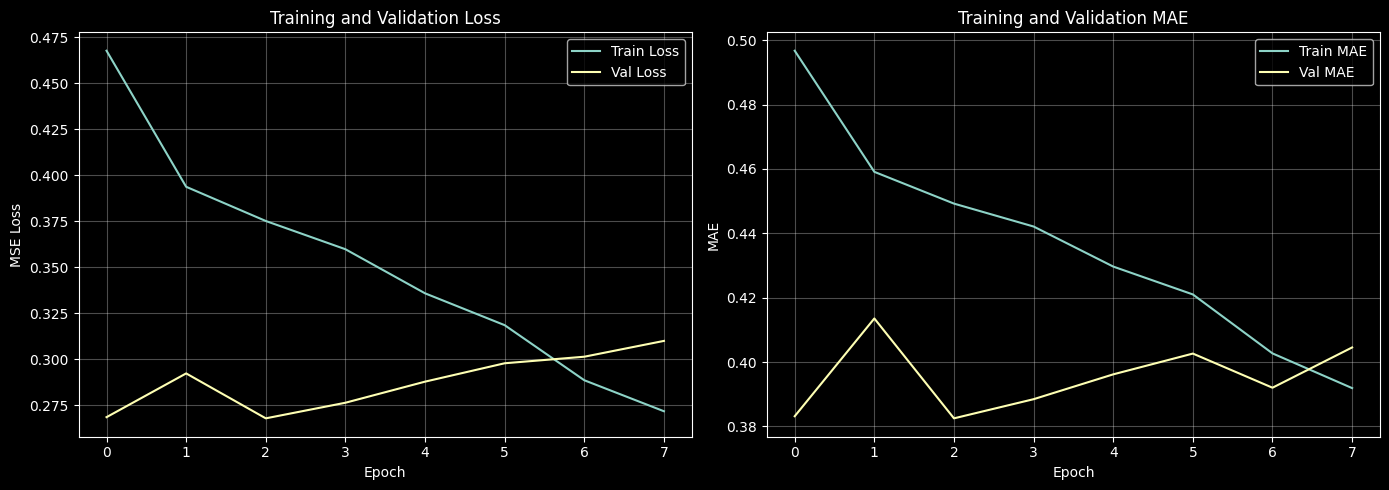

In [116]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train MAE")
ax2.plot(history.history["val_mae"], label="Val MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_title("Training and Validation MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate

In [117]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test MSE (scaled): {test_loss:.6f}")
print(f"Test MAE (scaled): {test_mae:.6f}")

# Compute metrics in original units
pred_all_scaled = model.predict(x_test)

pred_all = target_scaler.inverse_transform(
    pred_all_scaled.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

true_all = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

overall_mae = np.mean(np.abs(pred_all - true_all))
overall_rmse = np.sqrt(np.mean((pred_all - true_all) ** 2))

# MAPE (exclude near-zero values)
mask = np.abs(true_all) > 1.0
overall_mape = np.mean(np.abs((true_all[mask] - pred_all[mask]) / true_all[mask])) * 100

print(f"\nTest Results (original units):")
print(f"  Overall MAE:  {overall_mae:.2f} gCO\u2082eq/kWh")
print(f"  Overall RMSE: {overall_rmse:.2f} gCO\u2082eq/kWh")
print(f"  Overall MAPE: {overall_mape:.1f}%")

268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.2036 - mae: 0.3326
Test MSE (scaled): 0.203566
Test MAE (scaled): 0.332556
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step

Test Results (original units):
  Overall MAE:  21.25 gCO₂eq/kWh
  Overall RMSE: 28.43 gCO₂eq/kWh
  Overall MAPE: 36.1%


# Save Model

In [118]:
model.save(os.path.join(MODEL_DIR, "final_model.keras"))

# Convert to TFLite

In [119]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
]

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f"TFLite model saved: {TFLITE_PATH} ({size_kb:.1f} KB)")

INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmp4h1drpww\assets


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmp4h1drpww\assets


Saved artifact at 'C:\Users\jbro9\AppData\Local\Temp\tmp4h1drpww'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 168, 7), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2343632056016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632055824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632057168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632056208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632054480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632060048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632048912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632059472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632059088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2343632059856: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite m

# Save Hyperparameters

In [120]:
params = {
    "model": "LSTM",
    "window_size": WINDOW_SIZE,
    "forecast_horizon": FORECAST_HORIZON,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "features": FEATURES
}

with open("model_params_lstm.json", "w") as f:
    json.dump(params, f, indent=4)

print("Training complete.")

Training complete.


# One Random 24h Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


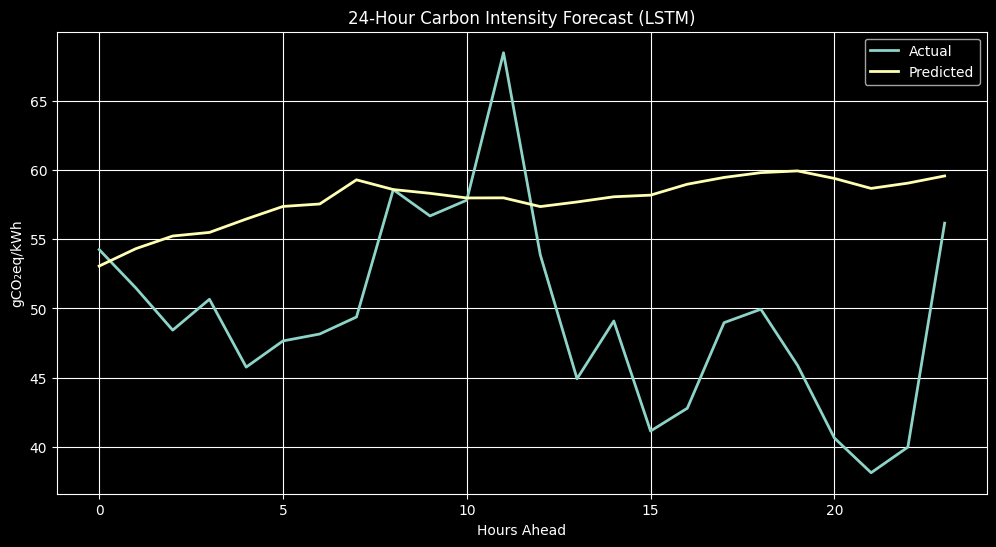

Sample MAE: 9.26 gCO₂eq/kWh


In [121]:
# Pick random test sample
idx = np.random.randint(0, len(x_test))

input_sample = x_test[idx:idx+1]
true_future_scaled = y_test[idx]

# Predict
pred_scaled = model.predict(input_sample)[0]

# Inverse scale
true_future = target_scaler.inverse_transform(
    true_future_scaled.reshape(-1, 1)
).flatten()

pred_future = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

# Plot
plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)

plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)

plt.title("24-Hour Carbon Intensity Forecast (LSTM)")
plt.xlabel("Hours Ahead")
plt.ylabel("gCO\u2082eq/kWh")
plt.legend()
plt.grid(True)
plt.show()

sample_mae = np.mean(np.abs(true_future - pred_future))
print(f"Sample MAE: {sample_mae:.2f} gCO\u2082eq/kWh")

# Best 3-Hour Charging Window

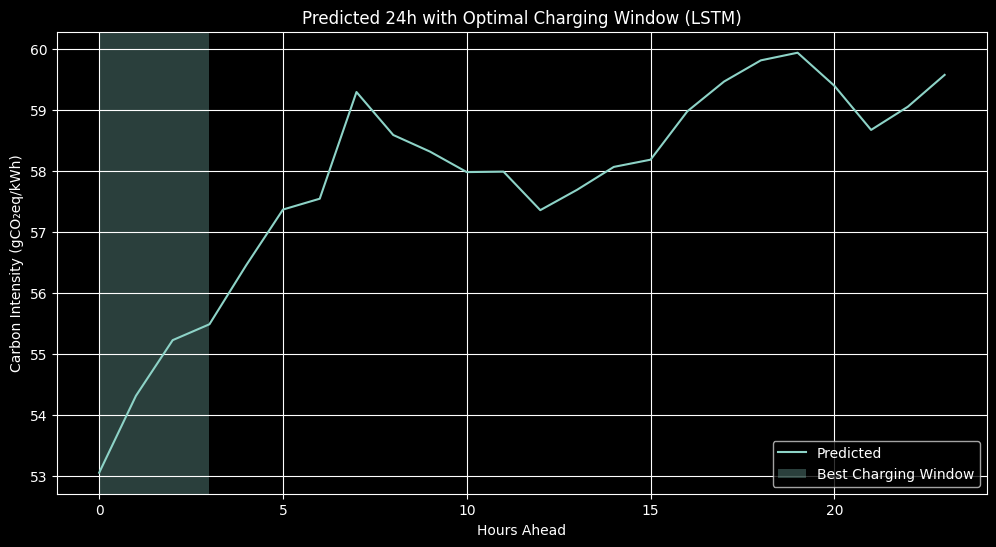

Best charging window: hour 0 to 3


In [122]:
window_size = 3

rolling_avg = np.convolve(
    pred_future,
    np.ones(window_size) / window_size,
    mode='valid'
)

best_start = np.argmin(rolling_avg)
best_end = best_start + window_size

plt.figure(figsize=(12, 6))
plt.plot(hours, pred_future, label="Predicted")

plt.axvspan(best_start, best_end,
            alpha=0.3,
            label="Best Charging Window")

plt.title("Predicted 24h with Optimal Charging Window (LSTM)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO\u2082eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best charging window: hour {best_start} to {best_end}")

# Evaluate Error Per Forecast Hour

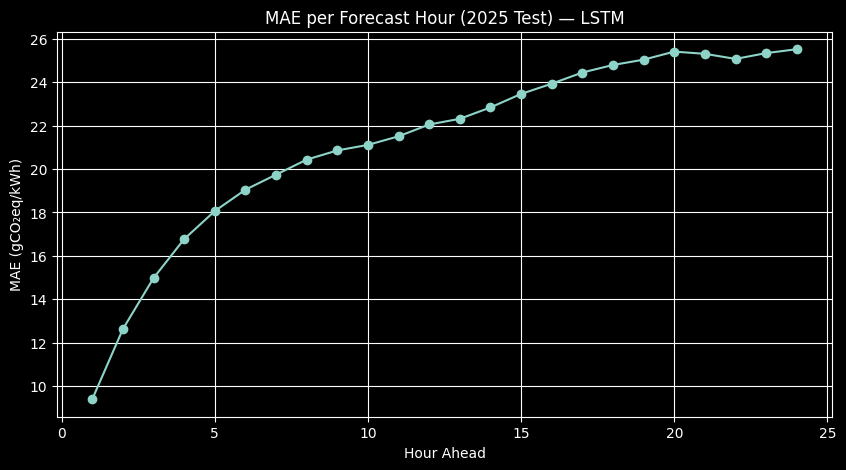

  Hour  1: MAE = 9.40 gCO₂eq/kWh
  Hour  6: MAE = 19.05 gCO₂eq/kWh
  Hour 12: MAE = 22.05 gCO₂eq/kWh
  Hour 18: MAE = 24.79 gCO₂eq/kWh
  Hour 24: MAE = 25.51 gCO₂eq/kWh


In [123]:
mae_per_hour = np.mean(np.abs(pred_all - true_all), axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(1, FORECAST_HORIZON+1), mae_per_hour, marker='o')
plt.title("MAE per Forecast Hour (2025 Test) — LSTM")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE (gCO\u2082eq/kWh)")
plt.grid(True)
plt.show()

# Print key horizons
for h in [0, 5, 11, 17, 23]:
    print(f"  Hour {h+1:2d}: MAE = {mae_per_hour[h]:.2f} gCO\u2082eq/kWh")

# Full 24h Forecast Distribution

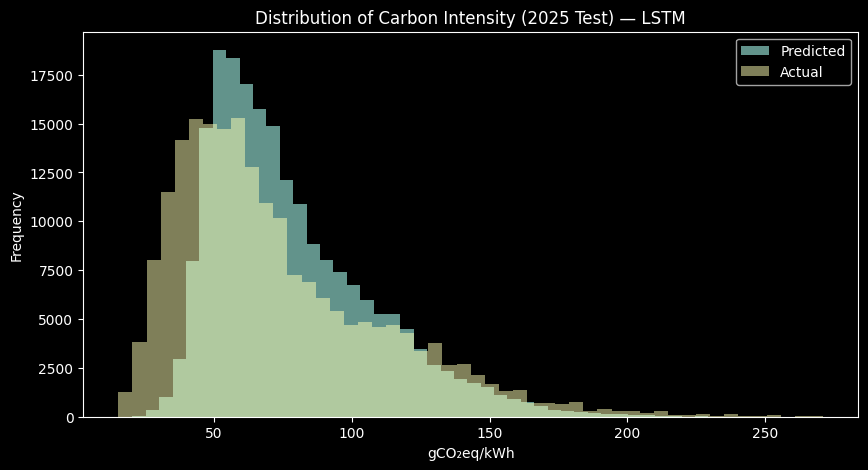

In [124]:
plt.figure(figsize=(10, 5))
plt.hist(pred_all.flatten(), bins=50, alpha=0.7, label="Predicted")
plt.hist(true_all.flatten(), bins=50, alpha=0.5, label="Actual")
plt.title("Distribution of Carbon Intensity (2025 Test) — LSTM")
plt.xlabel("gCO\u2082eq/kWh")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Summer vs Winter Performance

Spring MAE: 20.73 gCO₂eq/kWh
Summer MAE: 16.61 gCO₂eq/kWh
Autumn MAE: 22.38 gCO₂eq/kWh
Winter MAE: 25.77 gCO₂eq/kWh


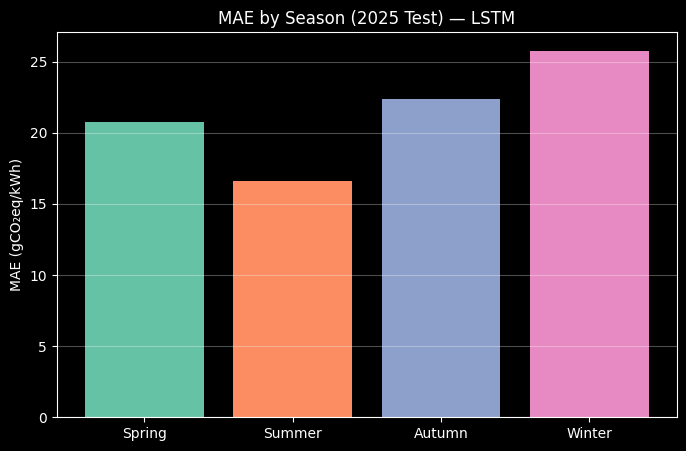

In [125]:
test_dates = test.iloc[WINDOW_SIZE:len(test)-FORECAST_HORIZON]["Datetime (UTC)"]

summer_mask = test_dates.dt.month.isin([6, 7, 8]).values
winter_mask = test_dates.dt.month.isin([12, 1, 2]).values
spring_mask = test_dates.dt.month.isin([3, 4, 5]).values
autumn_mask = test_dates.dt.month.isin([9, 10, 11]).values

summer_mae = np.mean(np.abs(pred_all[summer_mask] - true_all[summer_mask]))
winter_mae = np.mean(np.abs(pred_all[winter_mask] - true_all[winter_mask]))
spring_mae = np.mean(np.abs(pred_all[spring_mask] - true_all[spring_mask]))
autumn_mae = np.mean(np.abs(pred_all[autumn_mask] - true_all[autumn_mask]))

print(f"Spring MAE: {spring_mae:.2f} gCO\u2082eq/kWh")
print(f"Summer MAE: {summer_mae:.2f} gCO\u2082eq/kWh")
print(f"Autumn MAE: {autumn_mae:.2f} gCO\u2082eq/kWh")
print(f"Winter MAE: {winter_mae:.2f} gCO\u2082eq/kWh")

# Bar chart
seasons = ["Spring", "Summer", "Autumn", "Winter"]
maes = [spring_mae, summer_mae, autumn_mae, winter_mae]

plt.figure(figsize=(8, 5))
plt.bar(seasons, maes, color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"])
plt.title("MAE by Season (2025 Test) — LSTM")
plt.ylabel("MAE (gCO\u2082eq/kWh)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

# Scatter: Predicted vs Actual

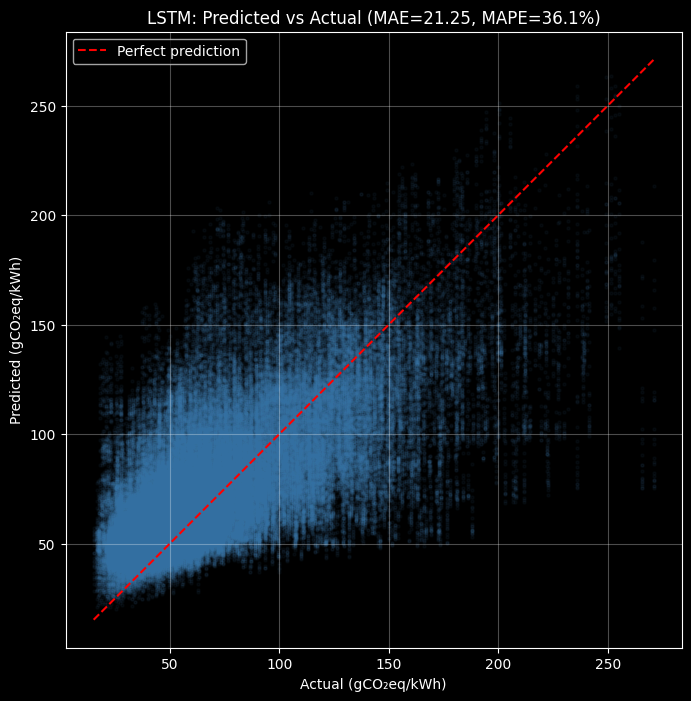

In [126]:
plt.figure(figsize=(8, 8))
pf = pred_all.flatten()
tf_ = true_all.flatten()
plt.scatter(tf_, pf, alpha=0.05, s=5, color="steelblue")
lims = [min(tf_.min(), pf.min()), max(tf_.max(), pf.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual (gCO\u2082eq/kWh)")
plt.ylabel("Predicted (gCO\u2082eq/kWh)")
plt.title(f"LSTM: Predicted vs Actual (MAE={overall_mae:.2f}, MAPE={overall_mape:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal")
plt.show()